In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# Load data

## Load the formants

In [2]:
# Load the .dat file without headers (adjust delimiter as needed)
df_all = pd.read_csv("Vowels/vowdata_nohead.dat", delimiter="\s+", header=None)

# Define the new column names (from vowdata.dat)
new_columns = [
    "Filename",
    "Duration in msec",
    "f0",
    "F1",
    "F2",
    "F3",
    "F4",
    "F1 at 20%",
    "F2 at 20%",
    "F3 at 20%",
    "F1 at 50%",
    "F2 at 50%",
    "F3 at 50%",
    "F1 at 80%",
    "F2 at 80%",
    "F3 at 80%"
]

# Assign the new column names to the dataframe
df_all.columns = new_columns
df_all['Class'] = df_all['Filename'].str[-2:]
df_all['Speaker'] = df_all['Filename'].str[0]
df_all.head()

,Filename,Duration in msec,f0,F1,F2,F3,F4,F1 at 20%,F2 at 20%,F3 at 20%,F1 at 50%,F2 at 50%,F3 at 50%,F1 at 80%,F2 at 80%,F3 at 80%,Class,Speaker
0,m01ae,323,174,663,2012,2659,3691,669,2008,2671,671,1992,2659,685,1773,2680,ae,m
1,m02ae,250,102,628,1871,2477,3489,627,1871,2456,636,1881,2455,628,1793,2451,ae,m
2,m03ae,344,99,605,1812,2570,0,608,1812,2572,618,1789,2618,632,1708,2693,ae,m
3,m04ae,312,124,627,1910,2488,3463,629,1882,2460,720,1750,2435,757,1563,2527,ae,m
4,m06ae,254,115,647,1864,2561,3506,642,1866,2557,666,1829,2499,689,1696,2556,ae,m


In [3]:

# Define the set of valid endings
valid_endings = {"ae", "ah", "aw"}

# Filter the dataframe
df = df_all[df_all['Filename'].str.endswith(tuple(valid_endings))]

# Pick only top three formants and 
df = df[['Filename', 'F1', 'F2', 'F3', 'Class', 'Speaker']]
classes = df['Class'].unique()

# Check that we have 139 * 3 data points
print(f'We have {len(df)} points in total so {int(len(df)/len(valid_endings))} samples per each class')

# Display the resulting dataframe
df.head()

We have 417 points in total so 139 samples per each class


,Filename,F1,F2,F3,Class,Speaker
0,m01ae,663,2012,2659,ae,m
1,m02ae,628,1871,2477,ae,m
2,m03ae,605,1812,2570,ae,m
3,m04ae,627,1910,2488,ae,m
4,m06ae,647,1864,2561,ae,m


## Load vowelforms

In [4]:
import torchaudio

In [5]:
# Base folder (assuming your script is in the same directory as the "Wovels" folder)
base_folder = Path("Vowels")
subfolders = ["women", "men", "kids"]

# List to store all audio data as one big chunk
wav_data = []  # Each entry: (subfolder, file stem, waveform, sample_rate)

for sub in subfolders:
    folder = base_folder / sub
    for file in folder.glob("*.wav"):
        # Check if file stem is exactly 5 characters long and ends with one of the valid endings
        if len(file.stem) == 5 and file.stem[-2:] in valid_endings:
            waveform, sample_rate = torchaudio.load(str(file))  # Convert Path to string
            wav_data.append((sub, file.stem, waveform, sample_rate))

print(f"Loaded a total of {len(wav_data)} files meaning we have {int(len(wav_data)/len(valid_endings))} samples per class.")

# Example: Accessing a file (e.g., the first one loaded)
example_sub, example_name, example_audio, example_sr = wav_data[0]


Loaded a total of 417 files meaning we have 139 samples per class.


# Problem 1

In [6]:
import IPython.display as ipd
from IPython.display import display, HTML

In [7]:
def play_vowel_samples(selected_vowel, wav_data, desired_speakers=["w"], num_samples=1):
    """
    Parameters:
    - selected_vowel: The vowel ending to play
    - wav_data: The vow data
    - desired_speakers: List of speaker groups to extract, i.e. man, girl etc
    - num_samples (int): Number of samples per vowel to extract
    """
    
    # Initialize a dictionary to hold lists of samples for each speaker.
    selected_samples = {speaker: [] for speaker in desired_speakers}
    
    # Loop through the data and collect the samples
    for sample in wav_data:
        sub, stem, waveform, sample_rate = sample
        ending = stem[-2:]
        if ending == selected_vowel:
            speaker = stem[0] 
            if speaker in desired_speakers and len(selected_samples[speaker]) < num_samples:
                selected_samples[speaker].append(sample)
        
        # Stop if every desired speaker has at least num_samples samples.
        if all(len(selected_samples[s]) >= num_samples for s in desired_speakers):
            break

    # Display a title
    display(HTML(f"<h1><b>Playing the '{selected_vowel.upper()}' vowel samples</b></h1>"))
    
    # For each desired speaker, play each collected sample
    for speaker in desired_speakers:
        samples = selected_samples.get(speaker, [])
        if samples:
            for idx, sample in enumerate(samples):
                sub, stem, waveform, sample_rate = sample
                print(f"Playing file {stem}")
                ipd.display(ipd.Audio(waveform.numpy(), rate=sample_rate))
        else:
            print(f"No sample found for speaker {speaker}")

### Listen to vowels

In [8]:
play_vowel_samples("ae", wav_data, num_samples=2)
play_vowel_samples("ah", wav_data, num_samples=2)
play_vowel_samples("aw", wav_data, num_samples=2)

Playing file w37ae


Playing file w13ae


Playing file w06ah


Playing file w22ah


Playing file w17aw


Playing file w33aw


## Generate class based histograms

In [9]:
import matplotlib.pyplot as plt

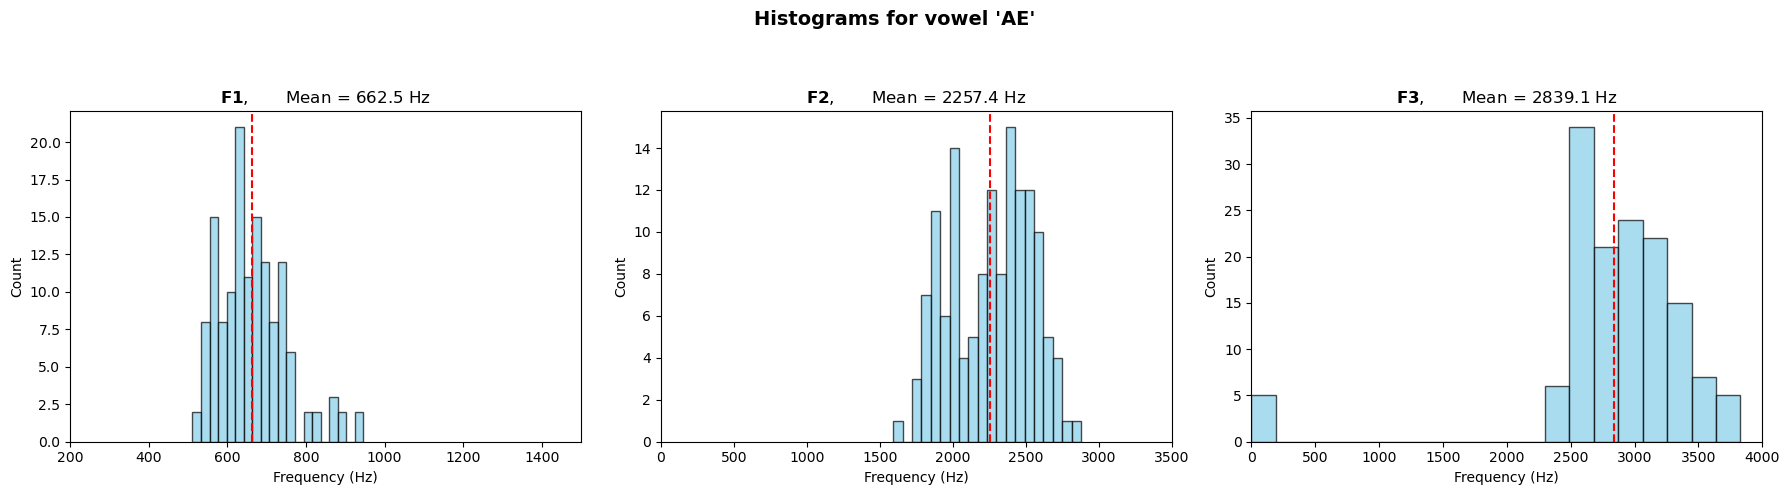

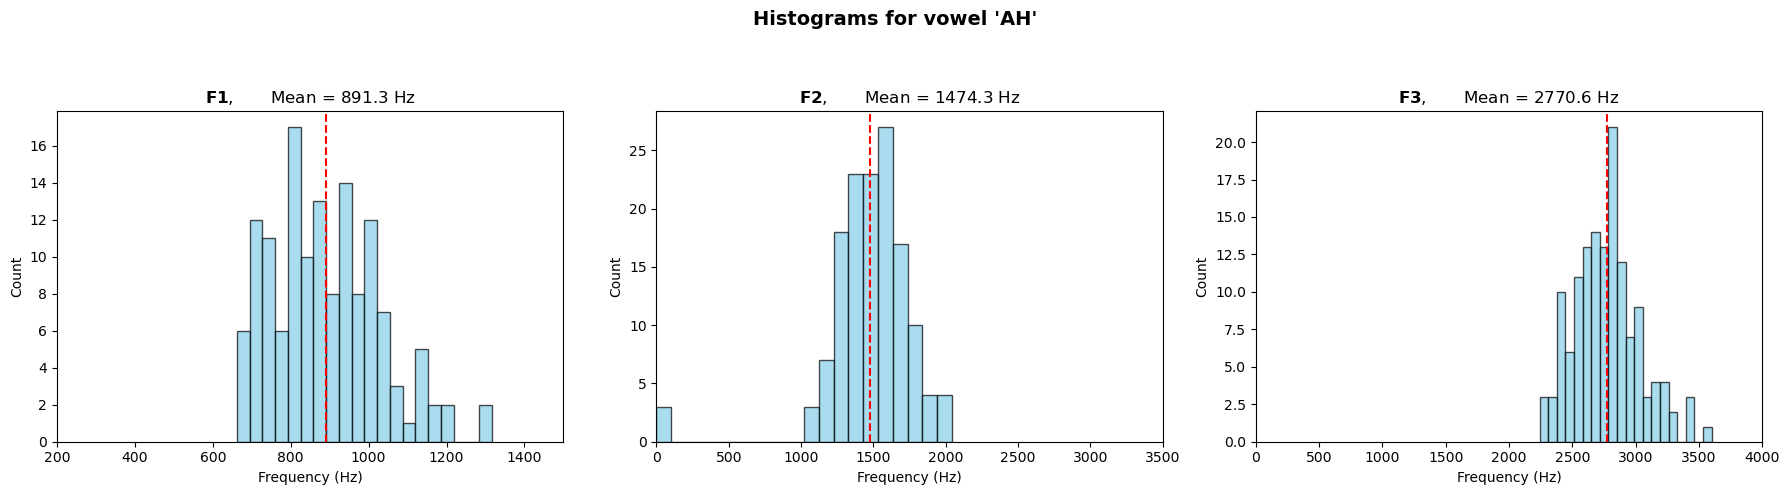

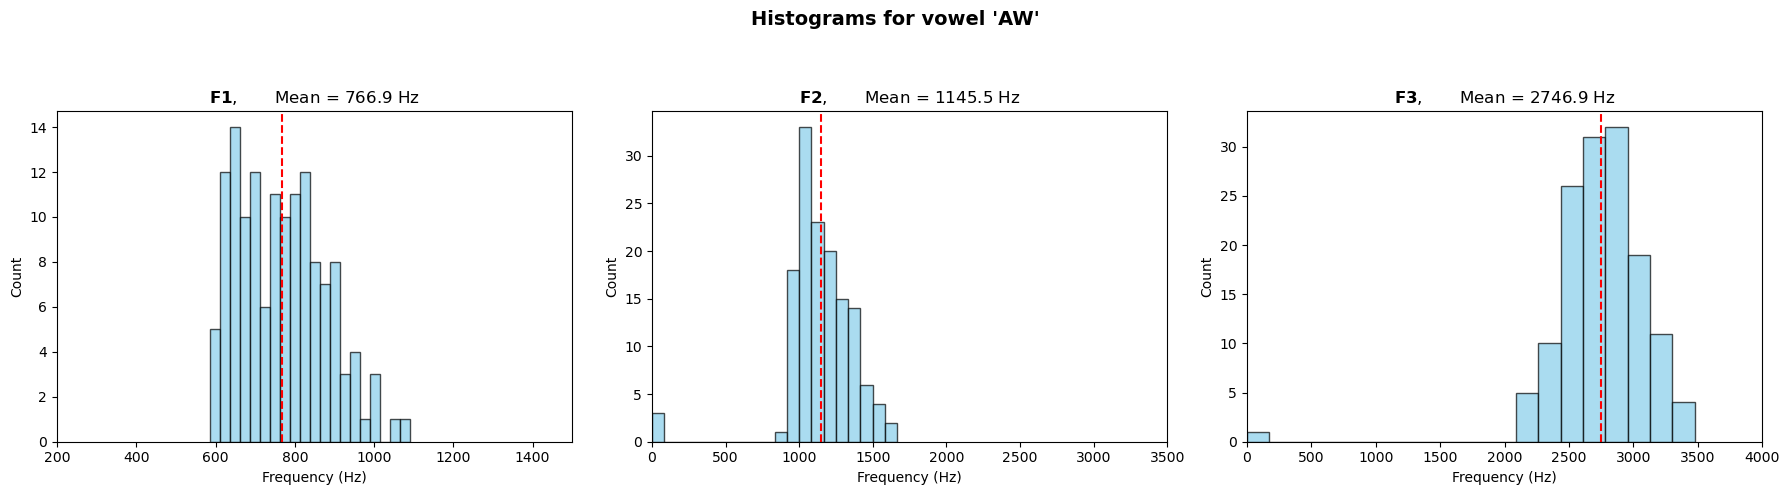

In [10]:
for vowel in classes:
    # Filter the training set for the current class
    class_data = df[df['Class'] == vowel]
    
    # Create a figure with 3 subplots for F1, F2, F3 histograms
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # List of formant labels (assumed column names)
    formants = ['F1', 'F2', 'F3']
    for i, formant in enumerate(formants):
        # Plot histogram with 20 bins, overlaying the mean frequency as a red dashed line
        data = class_data[formant].dropna()
        axs[i].hist(data, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
        mean_val = np.mean(data)
        axs[i].axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5)
        axs[i].set_title(f"$\\bf{{{formant}}}$, \t Mean = {mean_val:.1f} Hz")
        axs[i].set_xlabel("Frequency (Hz)")
        axs[i].set_ylabel("Count")
        if formant == "F1":
            axs[i].set_xlim(200, 1500)
        if formant == "F2":
            axs[i].set_xlim(0, 3500)
        if formant == "F3":
            axs[i].set_xlim(0, 4000)
            
    
    fig.suptitle(f"Histograms for vowel '{vowel.upper()}'", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

We can see that the the F1 formant has a similar distribution between different vowels whereas F2 and F3 are vary a bit more. With that said, it is relatively easy to distinguish between AE and AH based on the frequency values. 

F2 is very good for separating AW from AE as their distributions hardly have any overlap. F3 is more similar between the vowels, especially between AW and AH, so it might alone not be a good feature for vowel classification. 

Overall we see that AE is the easiest to distinguish from the other two since its format distributions differ the most from the other two.

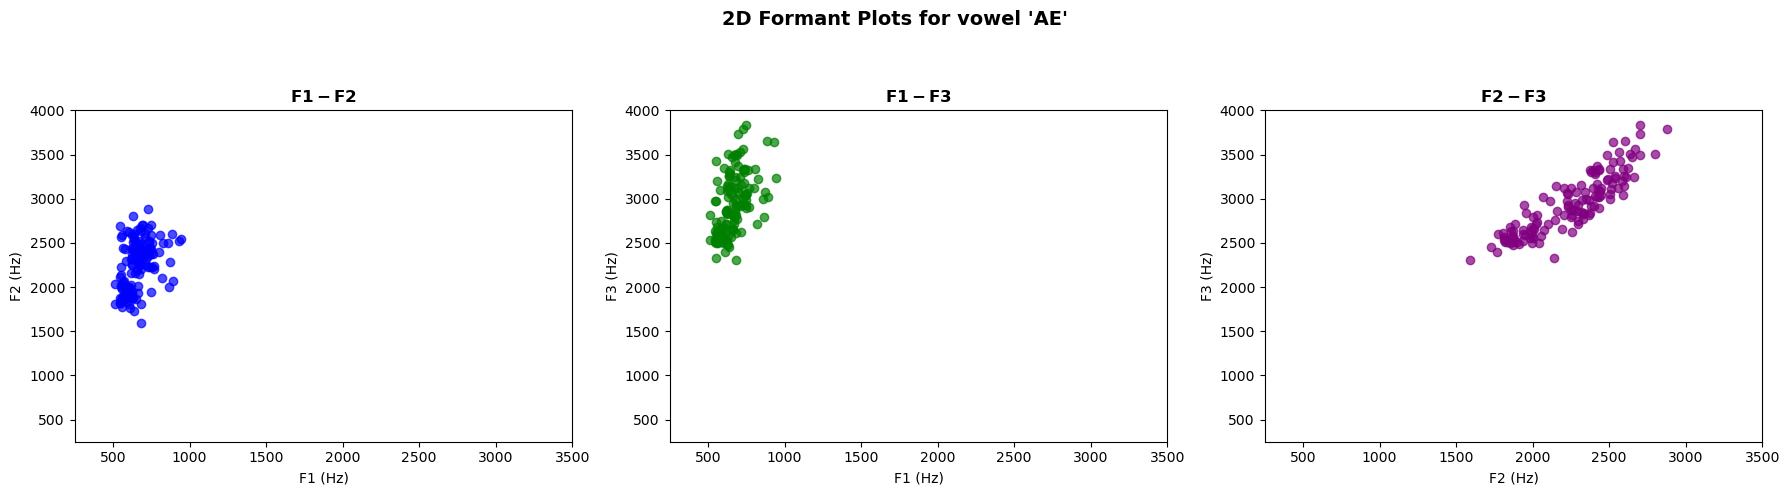

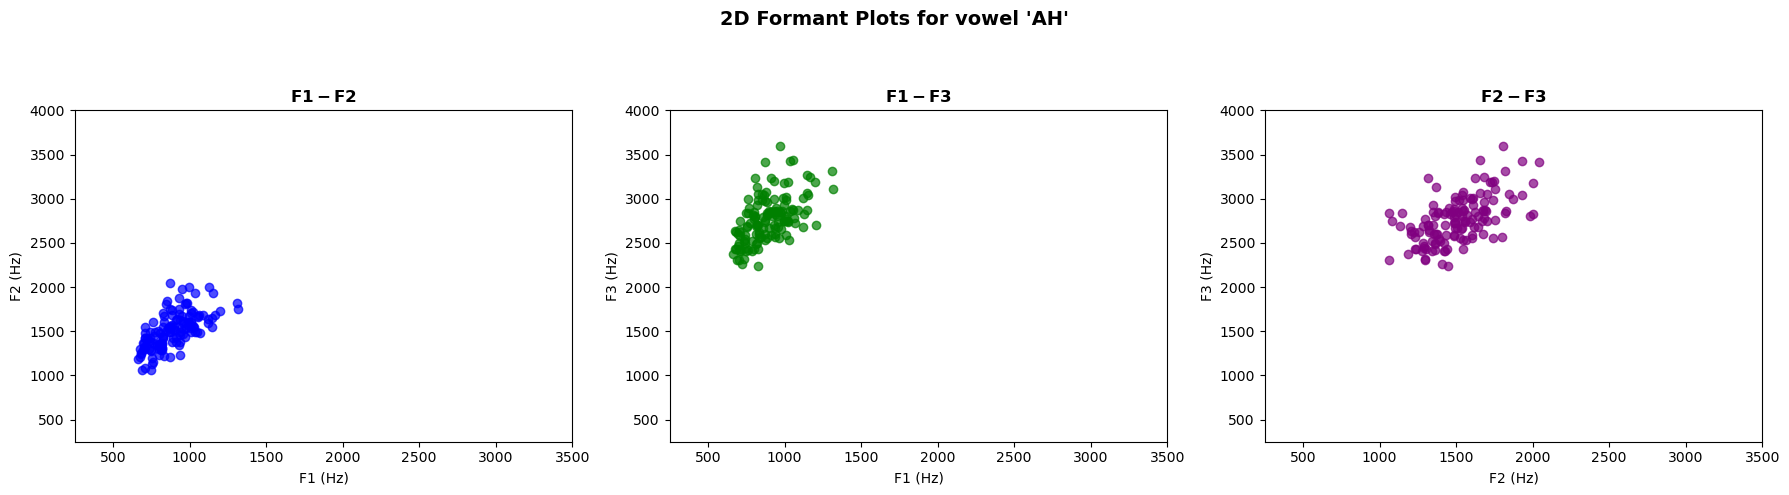

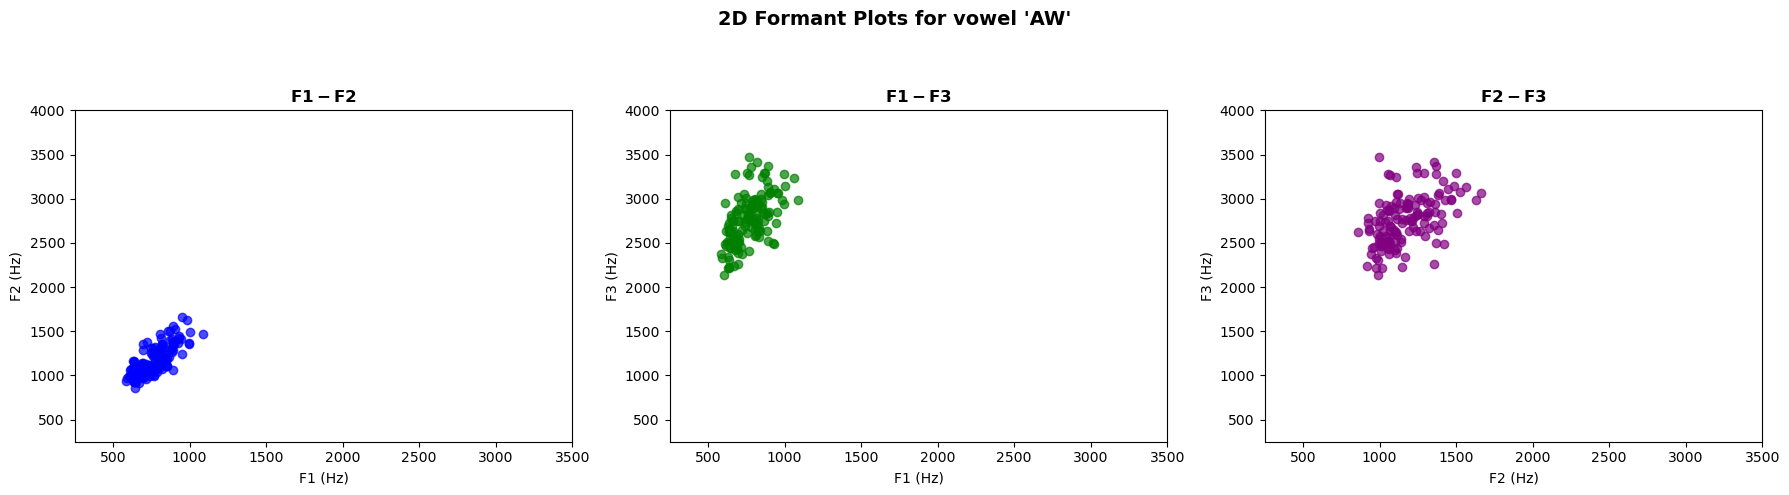

In [11]:
for vowel in classes:
    # Filter the training set for the current class
    class_data = df[df['Class'] == vowel]
    
    # Create a figure with 3 subplots for the 2D plots
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot F1 vs F2
    axs[0].scatter(class_data['F1'], class_data['F2'], color='blue', alpha=0.7)
    axs[0].set_xlabel("F1 (Hz)")
    axs[0].set_ylabel("F2 (Hz)")
    axs[0].set_title(r"$\bf{F1-F2}$")
    axs[0].set_ylim(250,4000)
    axs[0].set_xlim(250,3500)
    
    # Plot F1 vs F3
    axs[1].scatter(class_data['F1'], class_data['F3'], color='green', alpha=0.7)
    axs[1].set_xlabel("F1 (Hz)")
    axs[1].set_ylabel("F3 (Hz)")
    axs[1].set_title(r"$\bf{F1-F3}$")
    axs[1].set_ylim(250,4000)
    axs[1].set_xlim(250,3500)
    
    # Plot F2 vs F3
    axs[2].scatter(class_data['F2'], class_data['F3'], color='purple', alpha=0.7)
    axs[2].set_xlabel("F2 (Hz)")
    axs[2].set_ylabel("F3 (Hz)")
    axs[2].set_title(r"$\bf{F2-F3}$")   
    axs[2].set_ylim(250,4000)
    axs[2].set_xlim(250,3500)
    
    fig.suptitle(f"2D Formant Plots for vowel '{vowel.upper()}'", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


We see that F1-F2 has a clearer difference between the vowels indicating that it may be the best combination for repeating the vowels, whereas F1-F2 may be the least helpful format.

It is, however, again clear that AE is, most likely, the easiest to identify since all its formant pairs differ from the other two vowels. The difference between AH and AW is much less which indicate that the model may struggle with separating these to vowels from each other.

# Problem 2

### Set 1 

In [12]:
# Define set 1: the first 70 samples for each class.
set1_training_df = df.groupby("Class").head(70)
set1_testing_df = df.groupby("Class").tail(69)

features = ['F1', 'F2', 'F3']

### Train the classifier

In [13]:
# Dictionary to hold the Gaussian parameters for each class.
gaussian_models_set1 = {}

# Train the classifier: for each class compute the mean and covariance.
classes = set1_training_df['Class'].unique()
for cls in classes:
    # Filter samples belonging to this class.
    class_data = set1_training_df[set1_training_df['Class'] == cls][features].dropna().to_numpy()
    
    # Estimate the mean vector.
    mu = np.mean(class_data, axis=0)
    
    # Estimate the covariance matrix.
    sigma = np.cov(class_data, rowvar=False) # Note: np.cov expects variables in rows, so set rowvar=False.
    
    # Store the parameters for this class.
    gaussian_models_set1[cls] = {'mean': mu, 'cov': sigma}

# Display the learned Gaussian parameters for each class.
for cls, params in gaussian_models_set1.items():
    print(f"Class: {cls}")
    print(f"Mean: {params['mean']}")
    print(f"Covariance Matrix:\n{params['cov']}\n")


Class: ae
Mean: [ 620.48571429 2066.55714286 2732.85714286]
Covariance Matrix:
[[ 3955.44182195  5103.69648033  6796.63561077]
 [ 5103.69648033 53592.91697723 48723.80538302]
 [ 6796.63561077 48723.80538302 60271.7184265 ]]

Class: ah
Mean: [ 814.01428571 1388.28571429 2629.4       ]
Covariance Matrix:
[[11336.21718427 11346.30020704 10911.67536232]
 [11346.30020704 25913.91718427 11947.33333333]
 [10911.67536232 11947.33333333 36897.22898551]]

Class: aw
Mean: [ 706.04285714 1087.9        2614.4       ]
Covariance Matrix:
[[ 7057.89668737  8109.01884058  8955.05507246]
 [ 8109.01884058 15766.26521739 10396.91014493]
 [ 8955.05507246 10396.91014493 46784.70724638]]



### Define models for classifying and evaluating the models

In [14]:
from scipy.stats import multivariate_normal
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
def classify_sample(sample, models):
    """
    The method returns the class with the highest likelihood
    for a given a sample vector and dictionary of Gaussian models
    """
    likelihoods = {}
    for cls, params in models.items():
        rv = multivariate_normal(mean=params['mean'], cov=params['cov'])
        likelihoods[cls] = rv.pdf(sample)
        
    return max(likelihoods, key=likelihoods.get)

In [16]:
def evaluate_classifier(data, models):
    """
    The method returns the error rate, confusion matrix (and its labels)
    for the model evaluated on the data
    """
    actual = data['Class'].tolist()
    predictions = []
    
    for _, row in data.iterrows():
        sample = row[features].to_numpy()
        pred = classify_sample(sample, models)
        predictions.append(pred)
    
    # Compute error rate:
    error_rate = np.mean(np.array(actual) != np.array(predictions))
    
    # Build confusion matrix using scikit-learn's function.
    # Use the model keys to specify the label order.
    labels = list(models.keys())
    cm = confusion_matrix(actual, predictions, labels=labels)
    
    return error_rate, cm, labels

In [17]:
def plot_confusion_matrix(cm, labels, title):
    """
    Plots the confusion matrix as a heatmat
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

### Evaluate the training set

Training Set Error Rate: 0.0714


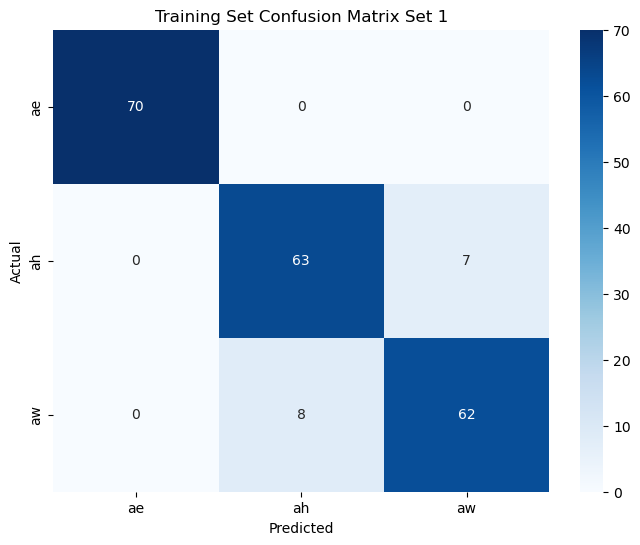

In [18]:
train_error_rate_set1, train_cm_set1, train_labels_set1  = evaluate_classifier(set1_training_df, gaussian_models_set1)
print(f"Training Set Error Rate: {train_error_rate_set1:.4f}")

plot_confusion_matrix(train_cm_set1, train_labels_set1, "Training Set Confusion Matrix Set 1")

### Evaluate on the test set

Test Set Error Rate: 0.1932


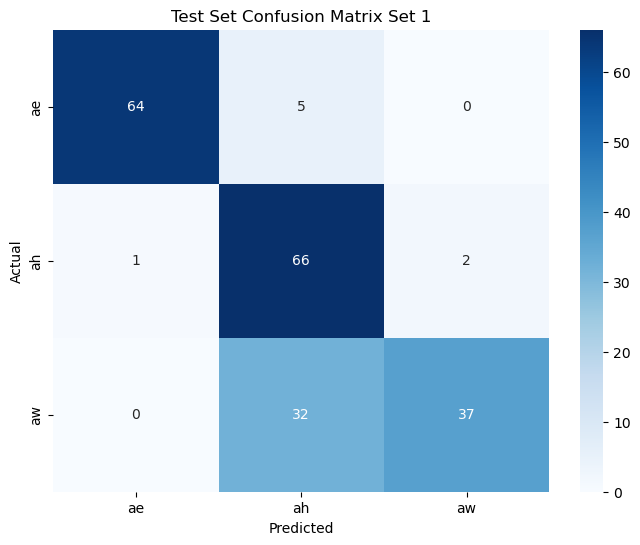

In [19]:
test_error_rate_set1, test_cm_set1, test_labels_set1 = evaluate_classifier(set1_testing_df, gaussian_models_set1)
print(f"Test Set Error Rate: {test_error_rate_set1:.4f}")
plot_confusion_matrix(test_cm_set1, test_labels_set1, "Test Set Confusion Matrix Set 1")

## Set 2

In [20]:
set2_training_df = df.groupby("Class").tail(69)
set2_testing_df = df.groupby("Class").head(70)

### Train the classifier

In [21]:
# Dictionary to hold the Gaussian parameters for each class.
gaussian_models_set2 = {}

# Train the classifier: for each class compute the mean and covariance.
classes = set2_training_df['Class'].unique()
for cls in classes:
    # Filter samples belonging to this class.
    class_data = set2_training_df[set2_training_df['Class'] == cls][features].dropna().to_numpy()
    
    # Estimate the mean vector.
    mu = np.mean(class_data, axis=0)
    
    # Estimate the covariance matrix.
    sigma = np.cov(class_data, rowvar=False) # Note: np.cov expects variables in rows, so set rowvar=False.
    
    # Store the parameters for this class.
    gaussian_models_set2[cls] = {'mean': mu, 'cov': sigma}

# Display the learned Gaussian parameters for each class.
for cls, params in gaussian_models_set2.items():
    print(f"Class: {cls}")
    print(f"Mean: {params['mean']}")
    print(f"Covariance Matrix:\n{params['cov']}\n")


Class: ae
Mean: [ 705.1884058  2451.08695652 2946.91304348]
Covariance Matrix:
[[  7669.59633419  -2053.78132992  21194.61956522]
 [ -2053.78132992  28540.78644501  11444.84590793]
 [ 21194.61956522  11444.84590793 758669.40409207]]

Class: ah
Mean: [ 969.60869565 1561.57971014 2913.92753623]
Covariance Matrix:
[[ 15638.56521739  -1064.8286445    8314.42710997]
 [ -1064.8286445  139397.62958227  13154.54262575]
 [  8314.42710997  13154.54262575  59584.89173061]]

Class: aw
Mean: [ 828.63768116 1204.         2881.27536232]
Covariance Matrix:
[[  9511.58738278   2847.02941176  15573.58653026]
 [  2847.02941176  92625.79411765   8865.83823529]
 [ 15573.58653026   8865.83823529 189739.37894288]]



### Evaluate on the training set

Training Set Error Rate: 0.1304


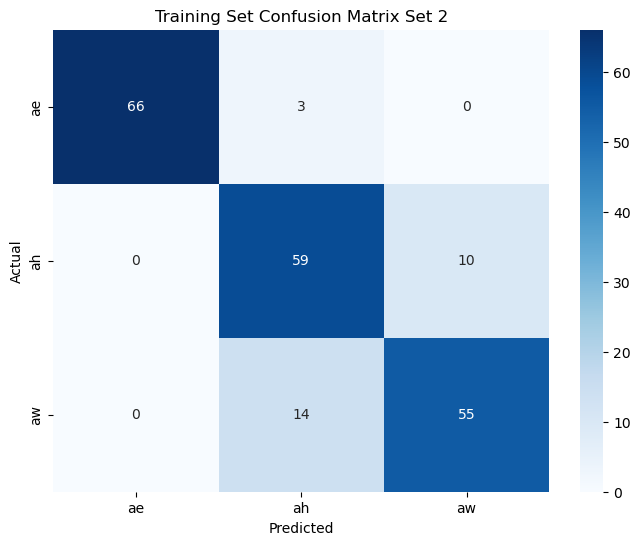

In [22]:
train_error_rate_set2, train_cm_set2, train_labels_set2 = evaluate_classifier(set2_training_df, gaussian_models_set2)
print(f"Training Set Error Rate: {train_error_rate_set2:.4f}")

plot_confusion_matrix(train_cm_set2, train_labels_set2, "Training Set Confusion Matrix Set 2")

### Evaluate on the test set

Test Set Error Rate: 0.4000


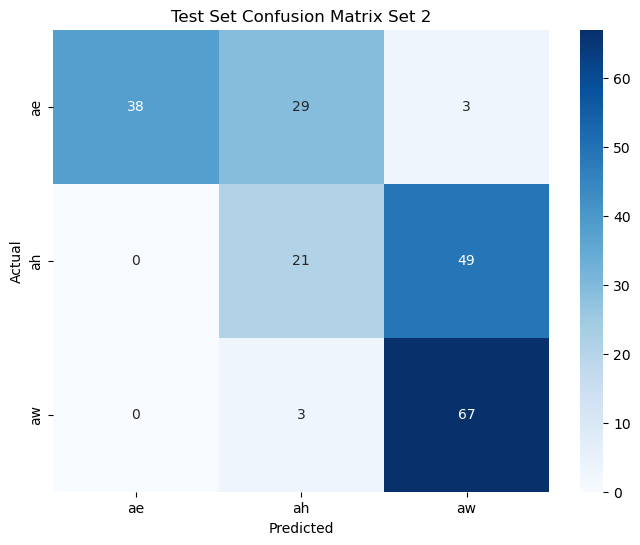

In [23]:
test_error_rate_set2, test_cm_set2, test_labels_set2 = evaluate_classifier(set2_testing_df, gaussian_models_set2)
print(f"Test Set Error Rate: {test_error_rate_set2:.4f}")
plot_confusion_matrix(test_cm_set2, test_labels_set2, "Test Set Confusion Matrix Set 2")

## Discussion 
The confusion matrices for set 1 agrees with the initial expression whereas the second case differences. 

The evaluation on the test set is worse than the training for both set 1 and set 2 which makes sense since these values are previously "unseen" to the model. There is in addition a great difference between the two sets, where training the model on the latter samples yield a worse generalization performance to unseen data. 

Looking at the distribution of speakers in the data some conclusions can be drawn for the great difference between sets. In set 2 the model trains on women and children, and is evaluated on men and women (see figure below). It thus makes sense that the model struggles more since men tend to have a deeper voice than children and women (which sound more alike), and it is something the model has not seen before. Listening to one vowel recording from each group confirms the suspected difference (see below)

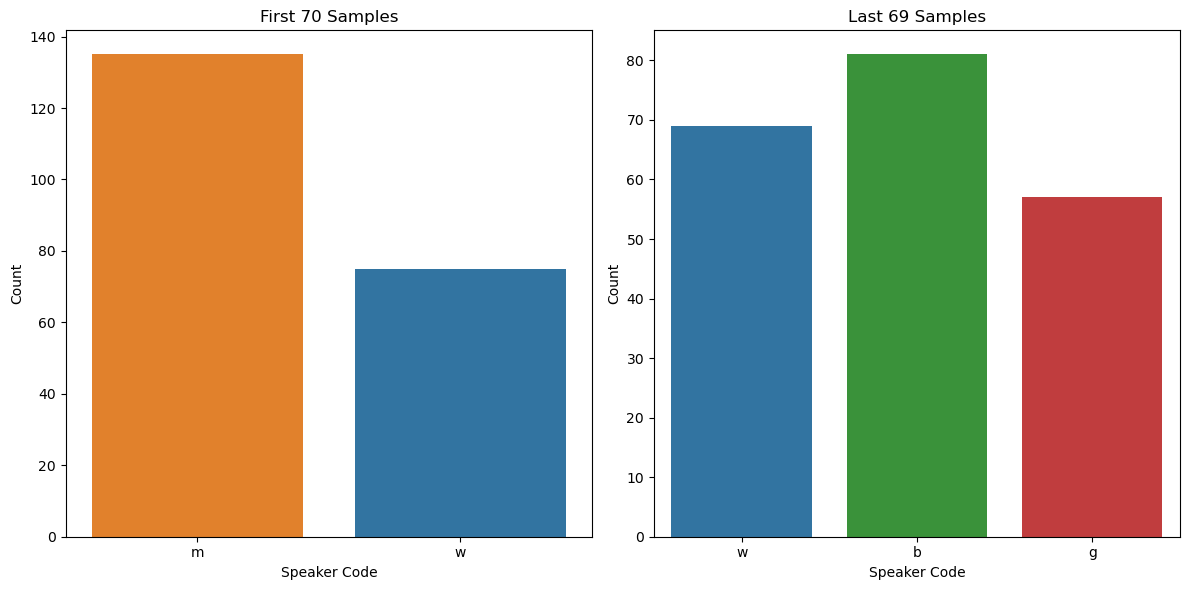

In [24]:
# Define a consistent color palette for the four potential speakers
color_palette = {"w": "#1f77b4",   # blue
              "m": "#ff7f0e",   # orange
              "b": "#2ca02c",   # green
              "g": "#d62728"}   # red
speaker_order = ['w', 'm', 'b', 'g']

# Create a 1x2 grid of subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Left subplot: set1_training_df (First 70 Samples)
sns.countplot(x='Speaker', data=set1_training_df, hue='Speaker',
              palette=color_palette, hue_order=speaker_order, dodge=False, ax=axs[0])
axs[0].set_title("First 70 Samples")
axs[0].set_xlabel("Speaker Code")
axs[0].set_ylabel("Count")
axs[0].legend([], [], frameon=False)

# Right subplot: set1_testing_df (Last 69 Samples)
sns.countplot(x='Speaker', data=set1_testing_df, hue='Speaker',
              palette=color_palette, hue_order=speaker_order, dodge=False, ax=axs[1])
axs[1].set_title("Last 69 Samples")
axs[1].set_xlabel("Speaker Code")
axs[1].set_ylabel("Count")
axs[1].legend([], [], frameon=False)

plt.tight_layout()
plt.show()


In [25]:
play_vowel_samples("ae", wav_data, desired_speakers=["w", "m", "g", "b"])
play_vowel_samples("aw", wav_data, desired_speakers=["w", "m", "g", "b"])

Playing file w37ae


Playing file m21ae


Playing file g06ae


Playing file b13ae


Playing file w17aw


Playing file m44aw


Playing file g02aw


Playing file b17aw
